In [1]:
file_path = "/home/hieunt/verl/temp/baseline_grpo_1e/per_question_statistics_latest.json"

import json

# Load the JSON data
with open(file_path, 'r') as f:
    data = json.load(f)

# Print a simple structure of the JSON file
def print_json_structure(obj, indent=0, max_items=5):
    prefix = '  ' * indent
    if isinstance(obj, dict):
        print(f"{prefix}dict with {len(obj)} keys: {list(obj.keys())[:max_items]}{' ...' if len(obj) > max_items else ''}")
        for k in list(obj.keys())[:max_items]:
            print(f"{prefix}  key: {k}")
            print_json_structure(obj[k], indent+2, max_items)
    elif isinstance(obj, list):
        print(f"{prefix}list of length {len(obj)}")
        if obj:
            print(f"{prefix}  first item:")
            print_json_structure(obj[0], indent+2, max_items)
    else:
        print(f"{prefix}{type(obj).__name__}")

print_json_structure(data)

dict with 17152 keys: ['c6c18e28-086f-4111-8e34-7c3b7b3e0538', 'b57078e1-3650-425b-a982-22189de7e057', '5af27c18-97b8-46a5-912b-95e9d3f65cc9', '855dbf2c-6557-47e0-a37c-7319d2cc9107', '3e73a641-8844-494d-87d3-c159b1ae67e3'] ...
  key: c6c18e28-086f-4111-8e34-7c3b7b3e0538
    dict with 6 keys: ['mean_acc_per_epoch', 'mean_score_per_epoch', 'std_acc_per_epoch', 'std_score_per_epoch', 'count_per_epoch'] ...
      key: mean_acc_per_epoch
        list of length 1
          first item:
            float
      key: mean_score_per_epoch
        list of length 1
          first item:
            float
      key: std_acc_per_epoch
        list of length 1
          first item:
            float
      key: std_score_per_epoch
        list of length 1
          first item:
            float
      key: count_per_epoch
        list of length 1
          first item:
            int
  key: b57078e1-3650-425b-a982-22189de7e057
    dict with 6 keys: ['mean_acc_per_epoch', 'mean_score_per_epoch', 'std_acc

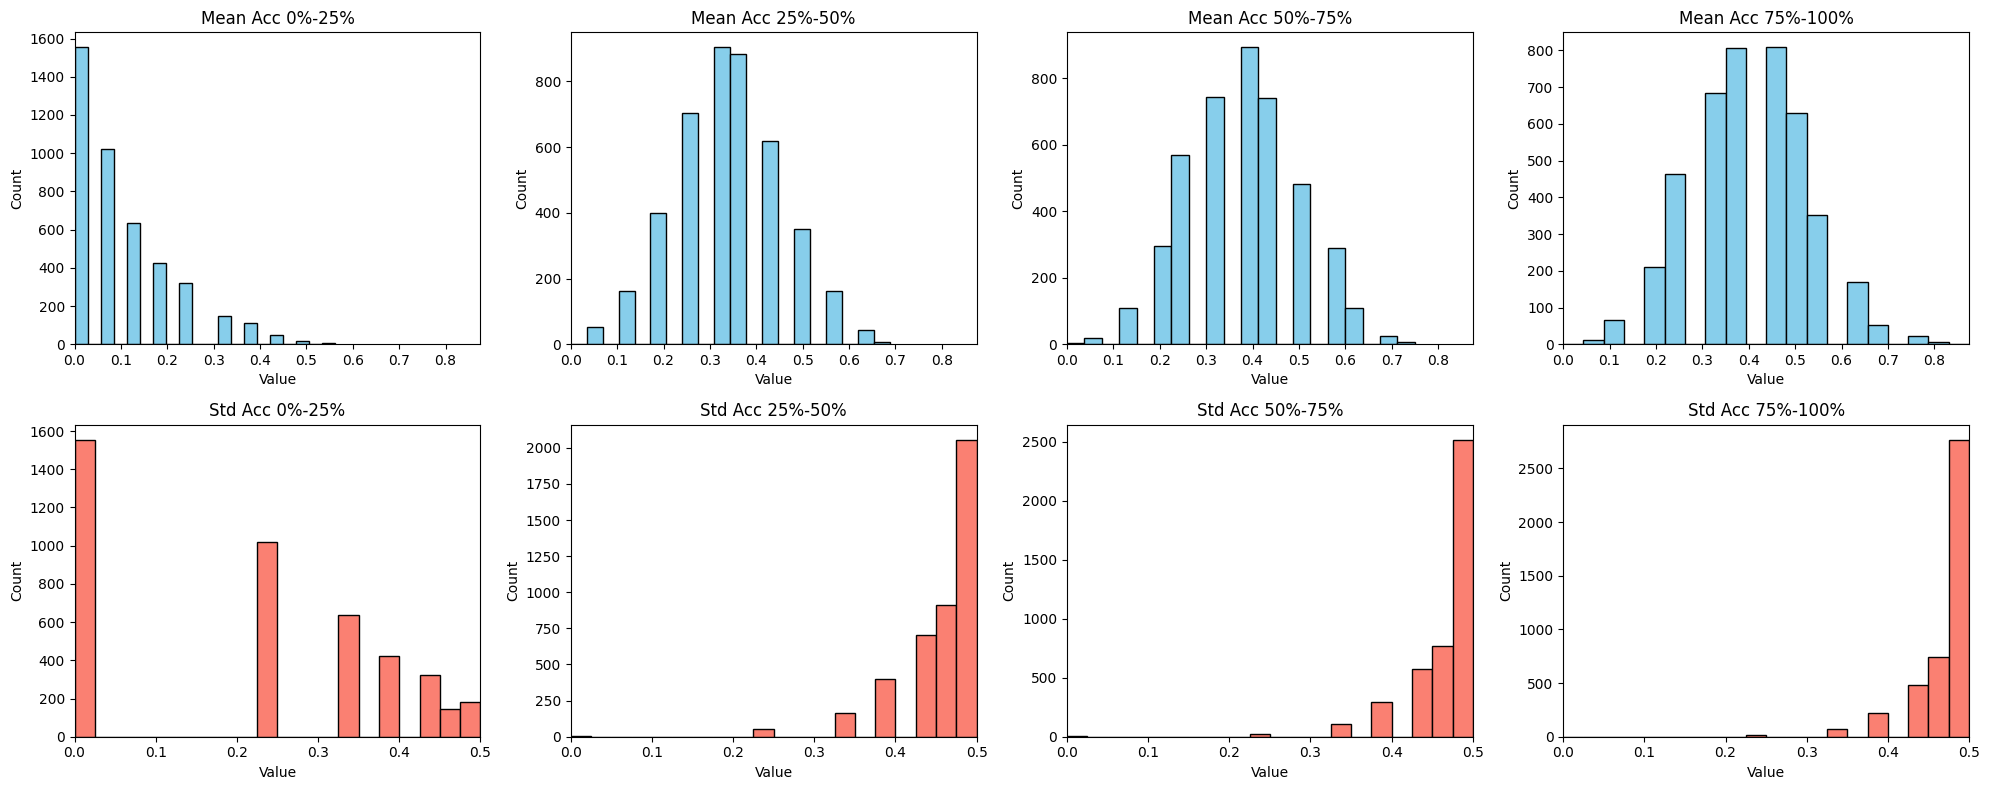

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Extract mean_acc_per_epoch and std_acc_per_epoch in time order
mean_acc = []
std_acc = []
for k in data:
    v = data[k]
    mean_acc.append(v.get('mean_acc_per_epoch', np.nan))
    std_acc.append(v.get('std_acc_per_epoch', np.nan))

mean_acc = np.array(mean_acc)
std_acc = np.array(std_acc)

# Split into 4 segments: 0-25%, 25-50%, 50-75%, 75-100%
n = len(mean_acc)
segments = [
    (0, int(0.25*n)),
    (int(0.25*n), int(0.5*n)),
    (int(0.5*n), int(0.75*n)),
    (int(0.75*n), n)
    ]

# Determine global x-axis ranges
acc_min, acc_max = np.nanmin(mean_acc), np.nanmax(mean_acc)
std_min, std_max = np.nanmin(std_acc), np.nanmax(std_acc)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (start, end) in enumerate(segments):
    axes[0, i].hist(mean_acc[start:end][~np.isnan(mean_acc[start:end])], bins=20, color='skyblue', edgecolor='black')
    axes[0, i].set_title(f"Mean Acc {int(100*start/n)}%-{int(100*end/n)}%")
    axes[0, i].set_xlim(acc_min, acc_max)
    axes[1, i].hist(std_acc[start:end][~np.isnan(std_acc[start:end])], bins=20, color='salmon', edgecolor='black')
    axes[1, i].set_title(f"Std Acc {int(100*start/n)}%-{int(100*end/n)}%")
    axes[1, i].set_xlim(std_min, std_max)

for ax in axes.flat:
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()